In [81]:
import os
import numpy as np
import scipp as sc
import MDAnalysis as mda
import matplotlib.pyplot as plt
from MDAnalysis.coordinates.memory import MemoryReader
from kinisi.analyze import DiffusionAnalyzer
from scipy.linalg import pinvh
from scipy.stats import linregress, spearmanr
from pathlib import Path
from tqdm import tqdm

In [82]:
base = Path.home()

(base / "data").mkdir(parents=True, exist_ok=True)

(base / "plots").mkdir(parents=True, exist_ok=True)

In [83]:
def walk(atoms, timesteps, jump_size, rng):
    """
    Simulate lattice random walks and return cumulative positions.

    Each step moves one walker by +/- jump_size along a single axis. The returned
    array has shape (atoms, timesteps, 3).

    """


    possible_moves = np.zeros((6, 3))

    axis = 0

    for i in range(0, 6, 2):
        possible_moves[i, axis] = jump_size
        possible_moves[i + 1, axis] = -jump_size
        axis += 1


    choices = rng.choice(6, size=(atoms, timesteps))
    steps = possible_moves[choices]
    return np.cumsum(steps, axis=1)

In [84]:
def build_analyzer(seed, atoms=128, length=128):
    """
    Build a kinisi DiffusionAnalyzer for one seeded random walk.

    Step size is sqrt(6), so the true diffusion coefficient is 1 once normalised.
    The analyser comes back with .diffusion() already called, which is what creates
    the .diff attribute everything else relies on.

    """


    rng = np.random.RandomState(seed)

    steps = walk(atoms, length, np.sqrt(6), rng)


    # a box large enough that nothing wraps
    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))


    u = mda.Universe.empty(steps.shape[0], trajectory=True)
    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])
    u.add_TopologyAttr('type', ['A'] * steps.shape[0])
    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)



    a = DiffusionAnalyzer.from_universe(
        u, time_step=1.0 * sc.Unit('s'), step_skip=1,
        distance_unit=sc.Unit('m'), specie='A',
        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                       stop=length * sc.Unit('s'), num=126),
        progress=False)


    a.diffusion(2 * sc.Unit('s'), progress=False)
    return a

In [85]:
# a quick check that the pipeline runs and gives sensible numbers


for s in range(8):
    a = build_analyzer(s)

    d_med = np.median(a.D.values)

    cond = np.linalg.cond(a.diff.covariance_matrix.values)
    
    print(f"seed {s}: D = {d_med:.4e}, cond = {cond:.3e}")

seed 0: D = 1.0054e+04, cond = 1.023e+16
seed 1: D = 9.9680e+03, cond = 2.975e+16
seed 2: D = 1.0120e+04, cond = 9.760e+15
seed 3: D = 9.9188e+03, cond = 1.444e+16
seed 4: D = 9.8288e+03, cond = 3.342e+07
seed 5: D = 1.0045e+04, cond = 1.131e+16
seed 6: D = 1.0278e+04, cond = 2.016e+16
seed 7: D = 1.0181e+04, cond = 1.060e+16


In [86]:
ckpt = base / "data" / "rw_32atoms_16k.npy"

n_seeds = 16000

atom_count = 32




def is_anomalous(d_value, d_typical):
    """
    Flag a fit as anomalous relative to the typical D for its system size.
    
    """

    if not np.isfinite(d_value):
        return True
    
    if d_value <= 0:
        return True
    
    ratio = d_value / d_typical

    return (ratio < 0.5) or (ratio > 2.0)





if os.path.exists(ckpt):
    records = list(np.load(ckpt, allow_pickle=True))

    done = {r["seed"] for r in records}

    print(f"resuming from {len(done)} done")

else:
    records, done = [], set()



if not done:
    probe = build_analyzer(0, atoms=atom_count)

    print(f"pre flight ok: seed 0 D={np.median(probe.D.values):.1f}")



fail_streak = 0



for s in tqdm(range(n_seeds)):
    if s in done:
        continue

    try:
        a = build_analyzer(s, atoms=atom_count)
        cov = a.diff.covariance_matrix.values
        ev = np.linalg.eigvalsh(cov)


        # i have written dict keys to disk , so do not rename them
        rec = {"seed": s,
               "D": float(np.median(a.D.values)),
               "D_std": float(np.std(a.D.values)),
               "cond": float(np.linalg.cond(cov)),
               "lmin": float(ev[0]),
               "lmax": float(ev[-1]),
               "frac_neg": float(np.mean(ev < 0))}
        fail_streak = 0



    except Exception as e:
        rec = {"seed": s, "D": np.nan, "cond": np.nan, "lmin": np.nan,
               "lmax": np.nan, "frac_neg": np.nan,
               "error": f"{type(e).__name__}: {e}"}
        fail_streak += 1
        if fail_streak >= 20:
            np.save(ckpt, np.array(records + [rec], dtype=object))
            raise RuntimeError("aborting beacuse there are 20 failures in a row, fix the error first")


    records.append(rec)
    if len(records) % 250 == 0:
        np.save(ckpt, np.array(records, dtype=object))



np.save(ckpt, np.array(records, dtype=object))

print(f"done: {len(records)} seeds")

resuming from 16000 done


100%|██████████| 16000/16000 [00:00<00:00, 9523040.16it/s]

done: 16000 seeds


In [87]:
records = list(np.load(ckpt, allow_pickle=True))

d_vals = np.array([r["D"] for r in records])
cond = np.array([r["cond"] for r in records])
seeds = np.array([r["seed"] for r in records])



finite = np.isfinite(d_vals)
d_typical = np.nanmedian(d_vals[finite & (d_vals > 0)])
anom = (~finite) | (d_vals <= 0) | (d_vals < 0.5 * d_typical) | (d_vals > 2 * d_typical)




print(f"total: {len(records)},  normal D scale: {d_typical:.2e}")

print(f"anomalous: {np.sum(anom)} ({100 * np.mean(anom):.3f}%)")

print(f"  D <= 0:            {np.sum(finite & (d_vals <= 0))}")

print(f"  near zero (<0.1N): {np.sum(finite & (d_vals > 0) & (d_vals < 0.1 * d_typical))}")

print(f"  high (>2N):        {np.sum(finite & (d_vals > 2 * d_typical))}")




print("\nconditioning link:")
print(f"  median cond normal:    {np.nanmedian(cond[~anom & finite]):.2e}")
print(f"  median cond anomalous: {np.nanmedian(cond[anom & finite]):.2e}")



bad_32 = seeds[anom]

print(f"\nbad seeds: {list(bad_32)}")

total: 16000,  normal D scale: 9.98e+03
anomalous: 3 (0.019%)
  D <= 0:            0
  near zero (<0.1N): 2
  high (>2N):        0

conditioning link:
  median cond normal:    1.59e+16
  median cond anomalous: 2.06e+16

bad seeds: [np.int64(295), np.int64(14460), np.int64(15770)]


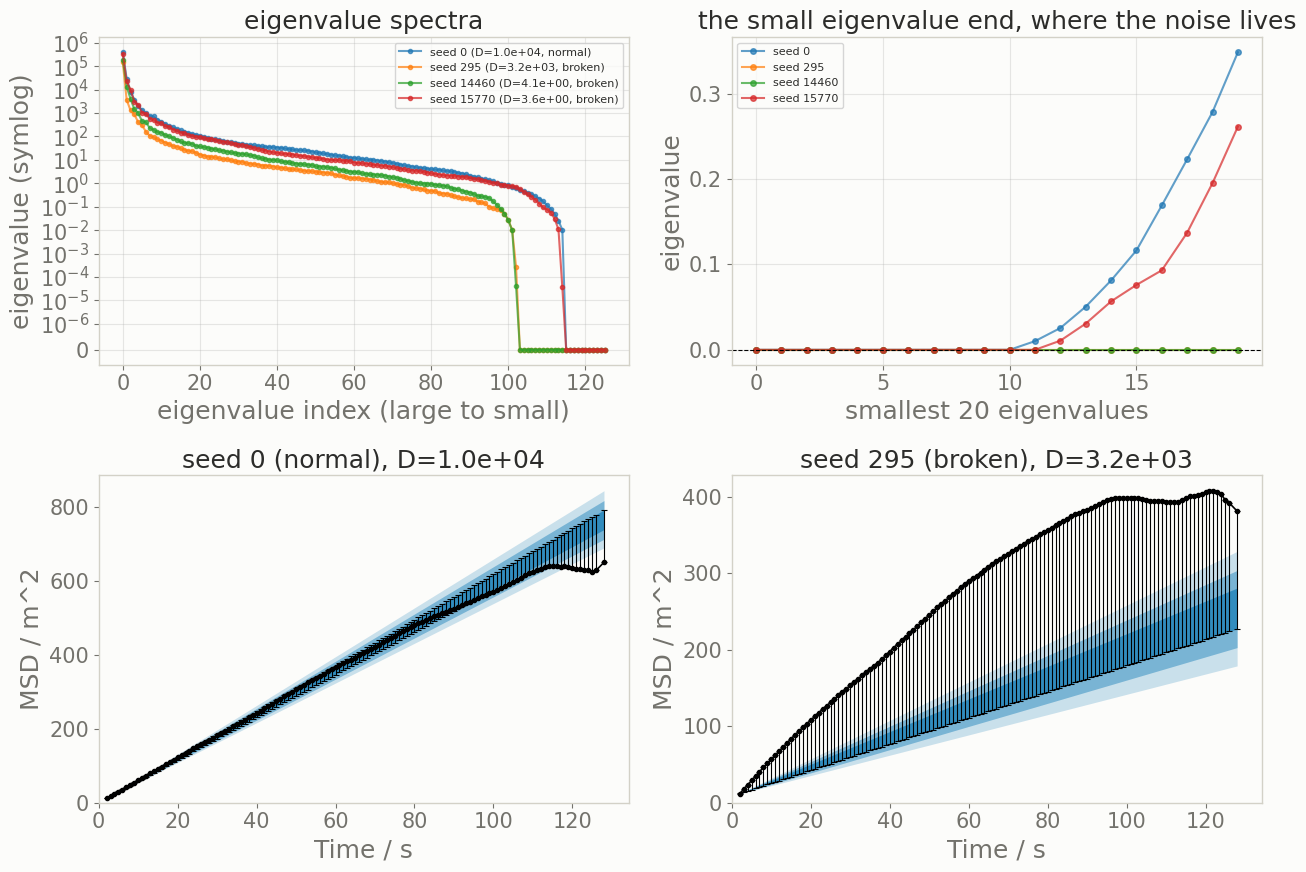

In [88]:
bad_seeds_32 = [295, 14460, 15770]

normal_seed = 0

fig, axes = plt.subplots(2, 2, figsize=(13, 9))



ax = axes[0, 0]
for s in [normal_seed] + bad_seeds_32:
    a = build_analyzer(s, atoms=32)
    ev = np.linalg.eigvalsh(a.diff.covariance_matrix.values)
    d_med = np.median(a.D.values)
    tag = 'normal' if s == normal_seed else 'broken'
    ax.plot(np.sort(ev)[::-1], 'o-', ms=3, alpha=0.7, label=f"seed {s} (D={d_med:.1e}, {tag})")
ax.set_yscale("symlog", linthresh=1e-6)
ax.set_xlabel("eigenvalue index (large to small)")
ax.set_ylabel("eigenvalue (symlog)")
ax.set_title("eigenvalue spectra")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)





ax = axes[0, 1]
for s in [normal_seed] + bad_seeds_32:
    a = build_analyzer(s, atoms=32)
    ev = np.sort(np.linalg.eigvalsh(a.diff.covariance_matrix.values))
    ax.plot(ev[:20], 'o-', ms=4, alpha=0.7, label=f"seed {s}")
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel("smallest 20 eigenvalues")
ax.set_ylabel("eigenvalue")
ax.set_title("the small eigenvalue end, where the noise lives")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)




credible_intervals = [[16, 84], [2.5, 97.5], [0.15, 99.85]]

band_alpha = [0.6, 0.4, 0.2]





for ax, s, tag in [(axes[1, 0], normal_seed, "normal"), (axes[1, 1], bad_seeds_32[0], "broken")]:
    a = build_analyzer(s, atoms=32)
    x = a.dt.values
    y = a.msd.values

    # 16 to 84 percentile band, roughly one sigma
    lo, hi = np.percentile(a.distributions, [16, 84], axis=1)
    yerr = np.vstack([np.maximum(y - lo, 0), np.maximum(hi - y, 0)])

    for i, ci in enumerate(credible_intervals):
        lo_ci, hi_ci = np.percentile(a.distributions, ci, axis=1)
        ax.fill_between(x, lo_ci, hi_ci, alpha=band_alpha[i], color="#0173B2", lw=0)

    ax.errorbar(x, y, yerr=yerr, fmt="o-", color="k", markersize=3, linewidth=1.2,
                elinewidth=0.8, capsize=2, capthick=0.8, label="MSD")
    ax.set_xlabel(f"Time / {a.dt.unit}")
    ax.set_ylabel(f"MSD / {a.msd.unit}")
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)
    ax.set_title(f"seed {s} ({tag}), D={np.median(a.D.values):.1e}")




plt.tight_layout()

plt.show()

In [89]:
for s in [0, 295, 14460, 15770]:
    a = build_analyzer(s, atoms=32)

    dt = a.dt.values

    msd = a.msd.values


    fit = linregress(dt, msd)

    linear = np.polyfit(dt, msd, 1)

    quadratic = np.polyfit(dt, msd, 2)



    resid_linear = np.sum((msd - np.polyval(linear, dt)) ** 2)

    resid_quad = np.sum((msd - np.polyval(quadratic, dt)) ** 2)

    improvement = 1 - resid_quad / resid_linear



    print(f"seed {s}: simple slope D = {fit.slope / (2 * 3):.1e}, "
          
          f"r^2 = {fit.rvalue ** 2:.4f}, "

          f"quad term = {quadratic[0]:+.3f}, "

          f"curvature reduces resid by {improvement:.1%}")

seed 0: simple slope D = 9.0e-01, r^2 = 0.9888, quad term = -0.015, curvature reduces resid by 76.4%
seed 295: simple slope D = 5.4e-01, r^2 = 0.9324, quad term = -0.026, curvature reduces resid by 93.5%
seed 14460: simple slope D = 7.4e-01, r^2 = 0.9912, quad term = -0.012, curvature reduces resid by 92.0%
seed 15770: simple slope D = 1.1e+00, r^2 = 0.9988, quad term = -0.004, curvature reduces resid by 34.6%


In [90]:
def build_raw_cov(a):

    """
    Rebuild the raw, un-reconditioned covariance from the stored MSD variances.

    kinisi keeps only the reconditioned matrix, so this reconstructs what it had
    before that step. Sliced to the diffusive regime, matching the fit.

    """


    da = a.diff.dg['da']
    variances = da.data.variances
    n_samples = da.coords['n_samples'].values


    n = variances.size

    cov = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            cov[i, j] = (n_samples[i] / n_samples[j]) * variances[i]
            cov[j, i] = cov[i, j]

    regime = a.diff.diff_regime
    return cov[regime:, regime:]




def gls_d_self(cov, t, y, dim=3, inverse="pinvh"):
    """
    Generalised least squares slope, as a quick stand in for the full Bayesian fit.
    
    """

    design = np.column_stack([t, np.ones_like(t)])

    inv = pinvh(cov) if inverse == "pinvh" else np.linalg.inv(cov)

    beta = np.linalg.solve(design.T @ inv @ design, design.T @ inv @ y)

    return beta[0] / (2 * dim)




def adaptive_floor(m, c=0.25):
    """
    Lift eigenvalues below c*|lambda_min| up to that floor. 

    """

    v, vecs = np.linalg.eigh(m)

    if v[0] < 0:
        floor = c * (-v[0]
                     )
        v = np.where(v < floor, floor, v)

    return (vecs * v) @ vecs.T



def mineig_floor(m, kappa=1e3):
    """
    Floor eigenvalues at lambda_max / kappa, i.e. target a fixed condition number.
    
    """

    v, vecs = np.linalg.eigh(m)

    floor = v[-1] / kappa

    return (vecs * np.where(v < floor, floor, v)) @ vecs.T

In [91]:
for seed in [15770, 14460, 295, 0]:
    a = build_analyzer(seed, atoms=32)

    raw = build_raw_cov(a)

    ev = np.linalg.eigvalsh(raw)



    regime = a.diff.diff_regime

    t = a.diff.dg['da'].coords['time interval'][regime:].values

    y = a.diff.dg['da']['time interval', regime:].values

    d_gls = gls_d_self(raw, t, y, inverse="pinvh")




    tag = "normal" if seed == 0 else "broken"

    print(f"seed {seed} ({tag}):")

    print(f"  raw smallest eig: {np.round(ev[:4], 5)}  (frac_neg {np.mean(ev < 0):.1%})")
    
    print(f"  self built GLS D (pinvh): {d_gls:.2f}")

seed 15770 (broken):
  raw smallest eig: [-1122.21108 -1009.17788  -241.70749   -81.01797]  (frac_neg 8.7%)
  self built GLS D (pinvh): -1.93
seed 14460 (broken):
  raw smallest eig: [-1903.80959  -803.41281  -390.27473  -193.33063]  (frac_neg 18.3%)
  self built GLS D (pinvh): -0.90
seed 295 (broken):
  raw smallest eig: [-1496.04249  -945.16825  -248.81847  -121.17913]  (frac_neg 18.3%)
  self built GLS D (pinvh): 0.33
seed 0 (normal):
  raw smallest eig: [-6802.34472  -942.21432  -463.59094  -178.54401]  (frac_neg 8.7%)
  self built GLS D (pinvh): 1.00


In [92]:
def realfit_with_treatment(seed, treatment_fn, atoms=32, start=2.0):
    """
    Run the real Bayesian fit with a treated covariance matrix injected.

    bayesian_regression rebuilds the covariance internally, so the only way to test a
    repair on the real fit is to monkey patch compute_covariance_matrix for the call.

    Returns the posterior samples of D, normalised so the true value is 1.

    """

    a = build_analyzer(seed, atoms=atoms)

    raw = build_raw_cov(a)

    treated = treatment_fn(raw)




    template = a.diff.compute_covariance_matrix()

    treated_var = sc.array(dims=template.dims, values=treated, unit=template.unit)




    original = a.diff.compute_covariance_matrix

    a.diff.compute_covariance_matrix = lambda: treated_var


    try:
        a.diff.bayesian_regression(start * sc.Unit('s'), progress=False)
        d_post = a.diff.gradient.values / (2 * 3)
    finally:
        a.diff.compute_covariance_matrix = original

    return d_post




seed = 15770

post_raw = realfit_with_treatment(seed, lambda m: m)

post_floored = realfit_with_treatment(seed, adaptive_floor)



print(f"seed {seed} (broken, target D = 1.0):")
print(f"  raw, no recondition: D median = {np.median(post_raw):.3f}")
print(f"  adaptive floor:      D median = {np.median(post_floored):.3f}")

seed 15770 (broken, target D = 1.0):
  raw, no recondition: D median = 0.000
  adaptive floor:      D median = 1.055


In [93]:
bad14 = [tuple(map(int, b)) for b in np.load(base / "data" / "all_bad_seeds_v2.npy")]

ckpt_fix = base / "data" / "anomaly_realfit_all14_v2.npy"



if os.path.exists(ckpt_fix):
    rows = list(np.load(ckpt_fix, allow_pickle=True))
    done = {(r["atoms"], r["seed"], r["method"]) for r in rows}
    print(f"resuming = {len(rows)} fits already done")



else:
    rows, done = [], set()



methods = [("raw", lambda m: m), ("adaptive", adaptive_floor), ("mineig1e3", mineig_floor)]



for atoms, seed in tqdm(bad14):
    todo = [(name, fn) for name, fn in methods if (atoms, seed, name) not in done]
    if not todo:
        continue

    a = build_analyzer(seed, atoms=atoms)
    d_ols = float(linregress(a.dt.values, a.msd.values).slope / (2 * 3))

    for name, fn in todo:
        try:
            post = realfit_with_treatment(seed, fn, atoms=atoms)
            rows.append({"atoms": atoms, "seed": seed, "method": name, "d_ols": d_ols,
                         "d": float(np.median(post)), "d_std": float(np.std(post))})
        except Exception as e:
            rows.append({"atoms": atoms, "seed": seed, "method": name, "d_ols": d_ols,
                         "d": np.nan, "d_std": np.nan, "error": f"{type(e).__name__}: {e}"})
        np.save(ckpt_fix, np.array(rows, dtype=object))

print(f"\n{'atoms':>5} {'seed':>6} {'d_ols':>7} {'raw':>8} {'adaptive':>9} {'mineig1e3':>10}")




for atoms, seed in bad14:
    group = {r["method"]: r for r in rows if r["atoms"] == atoms and r["seed"] == seed}
    if not group:
        continue
    vals = [group.get(m, {}).get("d", np.nan) for m in ("raw", "adaptive", "mineig1e3")]
    formatted = " ".join(f"{v:9.3f}" if np.isfinite(v) else f"{'nan':>9}" for v in vals)
    print(f"{atoms:5d} {seed:6d} {group['raw']['d_ols']:7.3f} {formatted}")

errs = [r for r in rows if "error" in r]



if errs:
    print("\nerrors:")
    for r in errs:
        print(f"  {r['atoms']} {r['seed']} {r['method']} >>> {r['error']}")

resuming = 42 fits already done


100%|██████████| 14/14 [00:00<00:00, 211986.48it/s]


atoms   seed   d_ols      raw  adaptive  mineig1e3
   32    295   0.545     0.329     0.579     0.482
   32  14460   0.741     0.000     0.838     0.836
   32  15770   1.103     0.000     1.049     1.058
   16      3   1.106     0.001     1.035     0.977
   16   2003   0.986     0.379     0.896     0.948
   16   8393   0.924     0.283     0.857     0.860
   16   9377   0.899     0.010     0.821     0.854
   16  13509   0.886     0.367     0.944     0.943
   24   1193   0.983     0.398     0.834     0.712
   24  13158   0.985     0.344     0.824     0.733
   48   9403   0.692     0.257     0.816     0.786
   48  13071   0.955     0.454     0.976     1.019
   48  13594   0.752     0.000     0.972     0.949
   48  14419   0.881     0.127     0.779     0.797


In [94]:
treatments = {"raw (no recond)": lambda m: m,
              "adaptive floor": adaptive_floor,
              "mineig 1e3": lambda m: mineig_floor(m, 1e3)}



print(f"{'seed':>7s} " + " ".join(f"{n:>16s}" for n in treatments) + "   target")



for seed in [0, 15770, 14460, 295]:
    row = []

    for name, fn in treatments.items():
        try:
            post = realfit_with_treatment(seed, fn)
            row.append(f"{np.median(post):16.3f}")
        except Exception:
            row.append(f"{'fail':>16s}")


    tag = "1.0 (normal)" if seed == 0 else "1.0 (broken)"
    
    print(f"{seed:7d} " + " ".join(row) + f"   {tag}")

   seed  raw (no recond)   adaptive floor       mineig 1e3   target
      0            0.994            0.977            0.951   1.0 (normal)
  15770            0.000            1.050            1.060   1.0 (broken)
  14460            0.000            0.843            0.838   1.0 (broken)
    295            0.326            0.575            0.488   1.0 (broken)


In [95]:
def model_variance_s15(a, kappa=np.sqrt(6), dim=3):
    """
    Analytical MSD variance from Eq. S-15, on the same lag grid as the analyser.
    
    """


    da = a.diff.dg['da']

    n_samples = da.coords['n_samples'].values

    n_steps = da.coords['time interval'].values

    regime = a.diff.diff_regime



    n = n_steps[regime:]

    n_prime = n_samples[regime:]

    return (2 * n ** 2 * kappa ** 4) / (dim * n_prime)




def cov_from_variance_s30(a, sigma2):
    """
    Build a full covariance matrix from a variance vector, using Eq. S-30.
    
    """

    da = a.diff.dg['da']

    n_samples = da.coords['n_samples'].values

    regime = a.diff.diff_regime

    n_prime = n_samples[regime:]


    k = sigma2.size

    cov = np.zeros((k, k))


    for i in range(k):

        for j in range(i, k):
            cov[i, j] = sigma2[i] * n_prime[i] / n_prime[j]

            cov[j, i] = cov[i, j]
            
    return cov

In [96]:
a0 = build_analyzer(0, atoms=32)

sigma2_true = model_variance_s15(a0)

cov_true = cov_from_variance_s30(a0, sigma2_true)

ev_true = np.linalg.eigvalsh(cov_true)



print(f"  smallest 5: {np.round(ev_true[:5], 4)}")

print(f"  largest:    {ev_true[-1]:.2f}")

print(f"  frac_neg:   {np.mean(ev_true < 0):.1%}  (zero, as expected for the noise free model)")

print(f"  condition:  {ev_true[-1] / ev_true[0]:.2e}" if ev_true[0] > 0 else "  singular")

  smallest 5: [0.012  0.0294 0.0539 0.0856 0.1245]
  largest:    345667.84
  frac_neg:   0.0%  (zero, as expected for the noise free model)
  condition:  2.88e+07


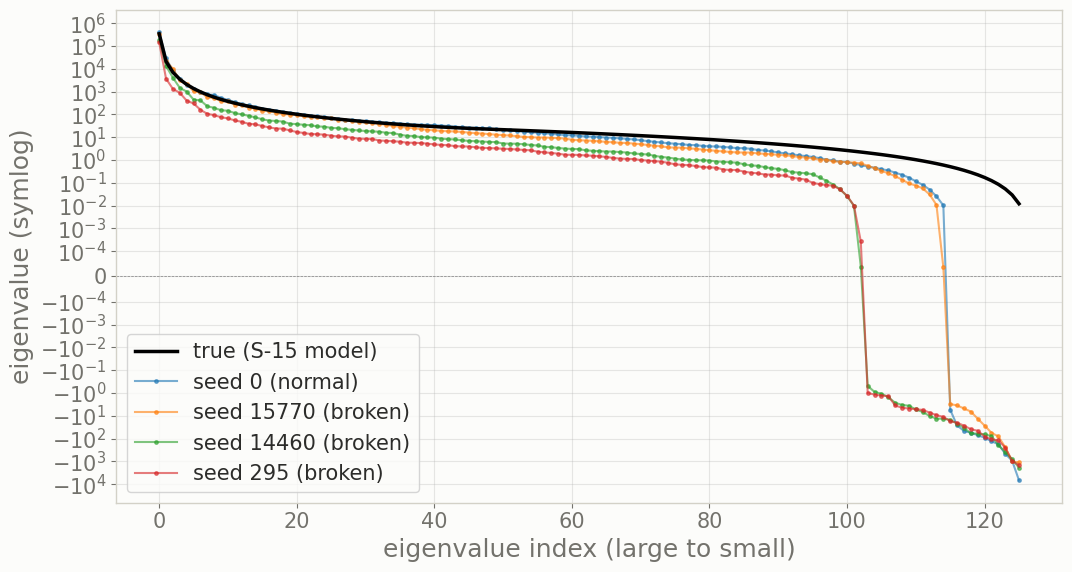

In [97]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(np.sort(ev_true)[::-1], 'k-', lw=2.5, label='true (S-15 model)', zorder=5)




for seed in [0, 15770, 14460, 295]:

    a = build_analyzer(seed, atoms=32)

    raw = build_raw_cov(a)

    ev = np.sort(np.linalg.eigvalsh(raw))[::-1]

    tag = 'normal' if seed == 0 else 'broken'

    ax.plot(ev, 'o-', ms=2.5, alpha=0.6, label=f'seed {seed} ({tag})')




ax.set_yscale('symlog', linthresh=1e-4)

ax.axhline(0, color='gray', lw=0.5, ls='--')

ax.set_xlabel('eigenvalue index (large to small)')

ax.set_ylabel('eigenvalue (symlog)')

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()


In [98]:
ckpt_scaling = base / "data" / "negatives_vs_atoms.npy"

atom_ladder = [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]



if os.path.exists(ckpt_scaling):
    scaling = list(np.load(ckpt_scaling, allow_pickle=True))
    done_counts = {r["atoms"] for r in scaling}
    print(f"resuming = {len(scaling)} sizes already done")


else:
    scaling, done_counts = [], set()


for n_atoms in atom_ladder:
    if n_atoms in done_counts:
        continue
    a = build_analyzer(0, atoms=n_atoms)
    ev = np.linalg.eigvalsh(build_raw_cov(a))
    scaling.append({"atoms": n_atoms,
                    "frac_neg": float(np.mean(ev < 0)),
                    "n_neg": int((ev < 0).sum()),
                    "lmin": float(ev[0])})
    np.save(ckpt_scaling, np.array(scaling, dtype=object))
    
    print(f"  {n_atoms:6d} atoms done")



scaling = sorted(scaling, key=lambda r: r["atoms"])

print(f"\n{'atoms':>7} {'frac_neg':>10} {'n_neg':>7} {'lmin':>13}")

for r in scaling:
    print(f"{r['atoms']:7d} {r['frac_neg']:10.3f} {r['n_neg']:7d} {r['lmin']:13.3e}")

resuming = 9 sizes already done

  atoms   frac_neg   n_neg          lmin
     64      0.048       6    -1.519e+02
    128      0.016       2    -3.356e+01
    256      0.024       3    -1.889e+01
    512      0.000       0     6.288e-04
   1024      0.008       1    -1.876e+00
   2048      0.008       1    -2.199e-01
   4096      0.008       1    -5.853e-02
   8192      0.000       0     3.923e-05
  16384      0.000       0     1.962e-05


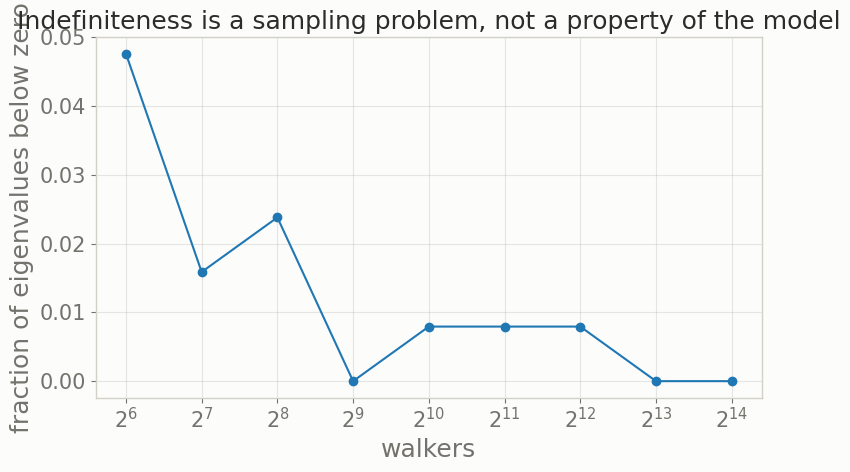

In [99]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot([r["atoms"] for r in scaling], [r["frac_neg"] for r in scaling],'o-', ms=6)

ax.set_xscale('log', base=2)

ax.set_xlabel('walkers')

ax.set_ylabel('fraction of eigenvalues below zero')

ax.set_title('Indefiniteness is a sampling problem, not a property of the model')

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('negatives_vs_atoms.png', dpi=150, bbox_inches='tight')

plt.show()

In [100]:
# Reference only. The population run lives in regenerate_population_v2.py file.
#
# from joblib import Parallel, delayed
#
# atom_counts = [16, 24, 32, 48]
# n_seeds = 16000
# ckpt_pop = base / "data" / "failure_population_v2.npy"
#
# true_ev = {}
# for ac in atom_counts:
#     a0 = build_analyzer(0, atoms=ac)
#     s2 = model_variance_s15(a0)
#     true_ev[ac] = np.sort(np.linalg.eigvalsh(cov_from_variance_s30(a0, s2)))[::-1]
#
# def fit_one(ac, s):
#     a = build_analyzer(s, atoms=ac)
#     raw = build_raw_cov(a)
#     ev = np.sort(np.linalg.eigvalsh(raw))[::-1]
#     pos = ev[ev > 0]
#     n = min(80, len(ev))
#     return {"atoms": ac, "seed": s,
#             "D": float(np.median(a.D.values)),
#             "cond": float(np.linalg.cond(a.diff.covariance_matrix.values)),
#             "frac_neg": float(np.mean(ev < 0)),
#             "n_pos": int(np.sum(ev > 0)),
#             "lmin": float(ev[-1]), "lmax": float(ev[0]),
#             "kappa_pos": float(ev[0] / pos[-1]) if pos.size else np.inf,
#             "bulk_dev": float(np.mean(np.log10(true_ev[ac][:n])
#                                       - np.log10(np.maximum(ev[:n], 1e-10))))}
#
# jobs = [(ac, s) for ac in atom_counts for s in range(n_seeds)]
# for i in range(0, len(jobs), 2000):
#     out = Parallel(n_jobs=-1, verbose=5)(delayed(fit_one)(ac, s) for ac, s in jobs[i:i+2000])
#     records.extend(out)
#     np.save(ckpt_pop, np.array(records, dtype=object))

print("bad list from the regenerated population:", bad14)

bad list from the regenerated population: [(32, 295), (32, 14460), (32, 15770), (16, 3), (16, 2003), (16, 8393), (16, 9377), (16, 13509), (24, 1193), (24, 13158), (48, 9403), (48, 13071), (48, 13594), (48, 14419)]


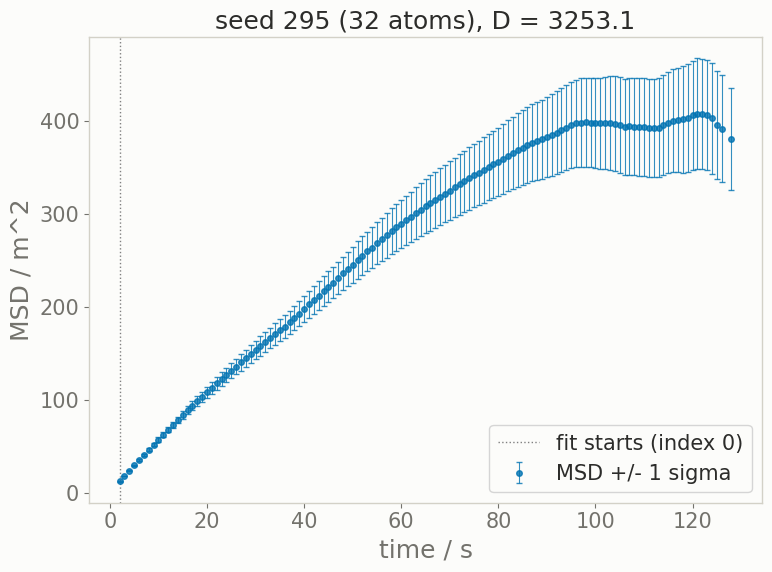

shapes >>> t: (126,) msd: (126,) var: (126,)
regime index: 0  D (median): 3253.0939167128963


In [101]:
a = build_analyzer(295, atoms=32)

t = a.dt.values

msd = a.msd.values




da = a.diff.dg['da']

var = da.data.variances

err = np.sqrt(var) if var is not None else None



regime = a.diff.diff_regime

d_med = float(np.median(a.D.values))




fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(t, msd, yerr=err, fmt='o', ms=4, color='#0173B2',
            ecolor='#0173B2', elinewidth=0.8, capsize=2, alpha=0.8, label='MSD +/- 1 sigma')

ax.axvline(t[regime], color='0.5', ls=':', lw=1, label=f'fit starts (index {regime})')

ax.set_xlabel(f'time / {a.dt.unit}')

ax.set_ylabel(f'MSD / {a.msd.unit}')

ax.set_title(f'seed 295 (32 atoms), D = {d_med:.1f}')

ax.legend()

plt.tight_layout()

plt.savefig('seed295_msd.png', dpi=150, bbox_inches='tight')

plt.show()


print("shapes >>> t:", t.shape, "msd:", msd.shape, "var:", None if var is None else var.shape)
print("regime index:", regime, " D (median):", d_med)

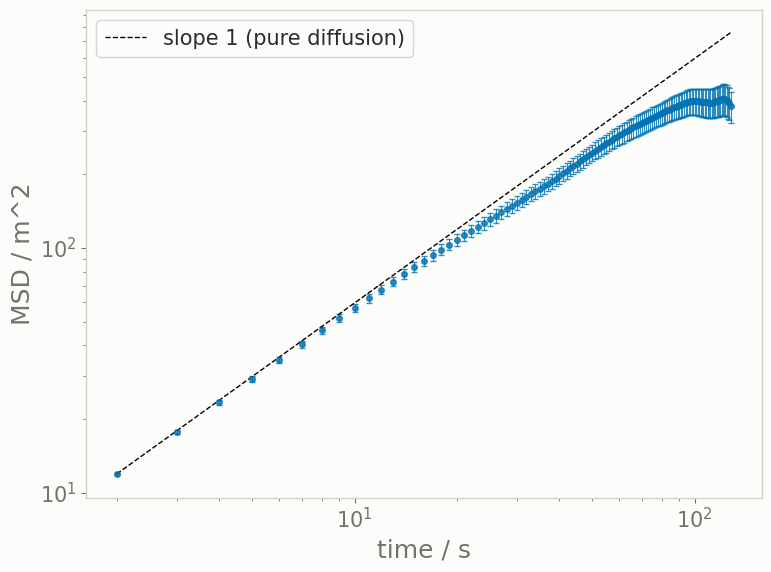

In [102]:
# same data on log-log axes, where pure diffusion is a straight line of slope 1


fig, ax = plt.subplots(figsize=(8, 6))

mask = msd > 0

ax.errorbar(t[mask], msd[mask], yerr=None if err is None else err[mask],
            fmt='o', ms=4, color='#0173B2', ecolor='#0173B2',
            elinewidth=0.8, capsize=2, alpha=0.8)



reference = msd[mask][0] * (t[mask] / t[mask][0])

ax.plot(t[mask], reference, 'k--', lw=1, label='slope 1 (pure diffusion)')

ax.set_xscale('log')

ax.set_yscale('log')

ax.set_xlabel(f'time / {a.dt.unit}')

ax.set_ylabel(f'MSD / {a.msd.unit}')

ax.legend()

plt.tight_layout()

plt.show()

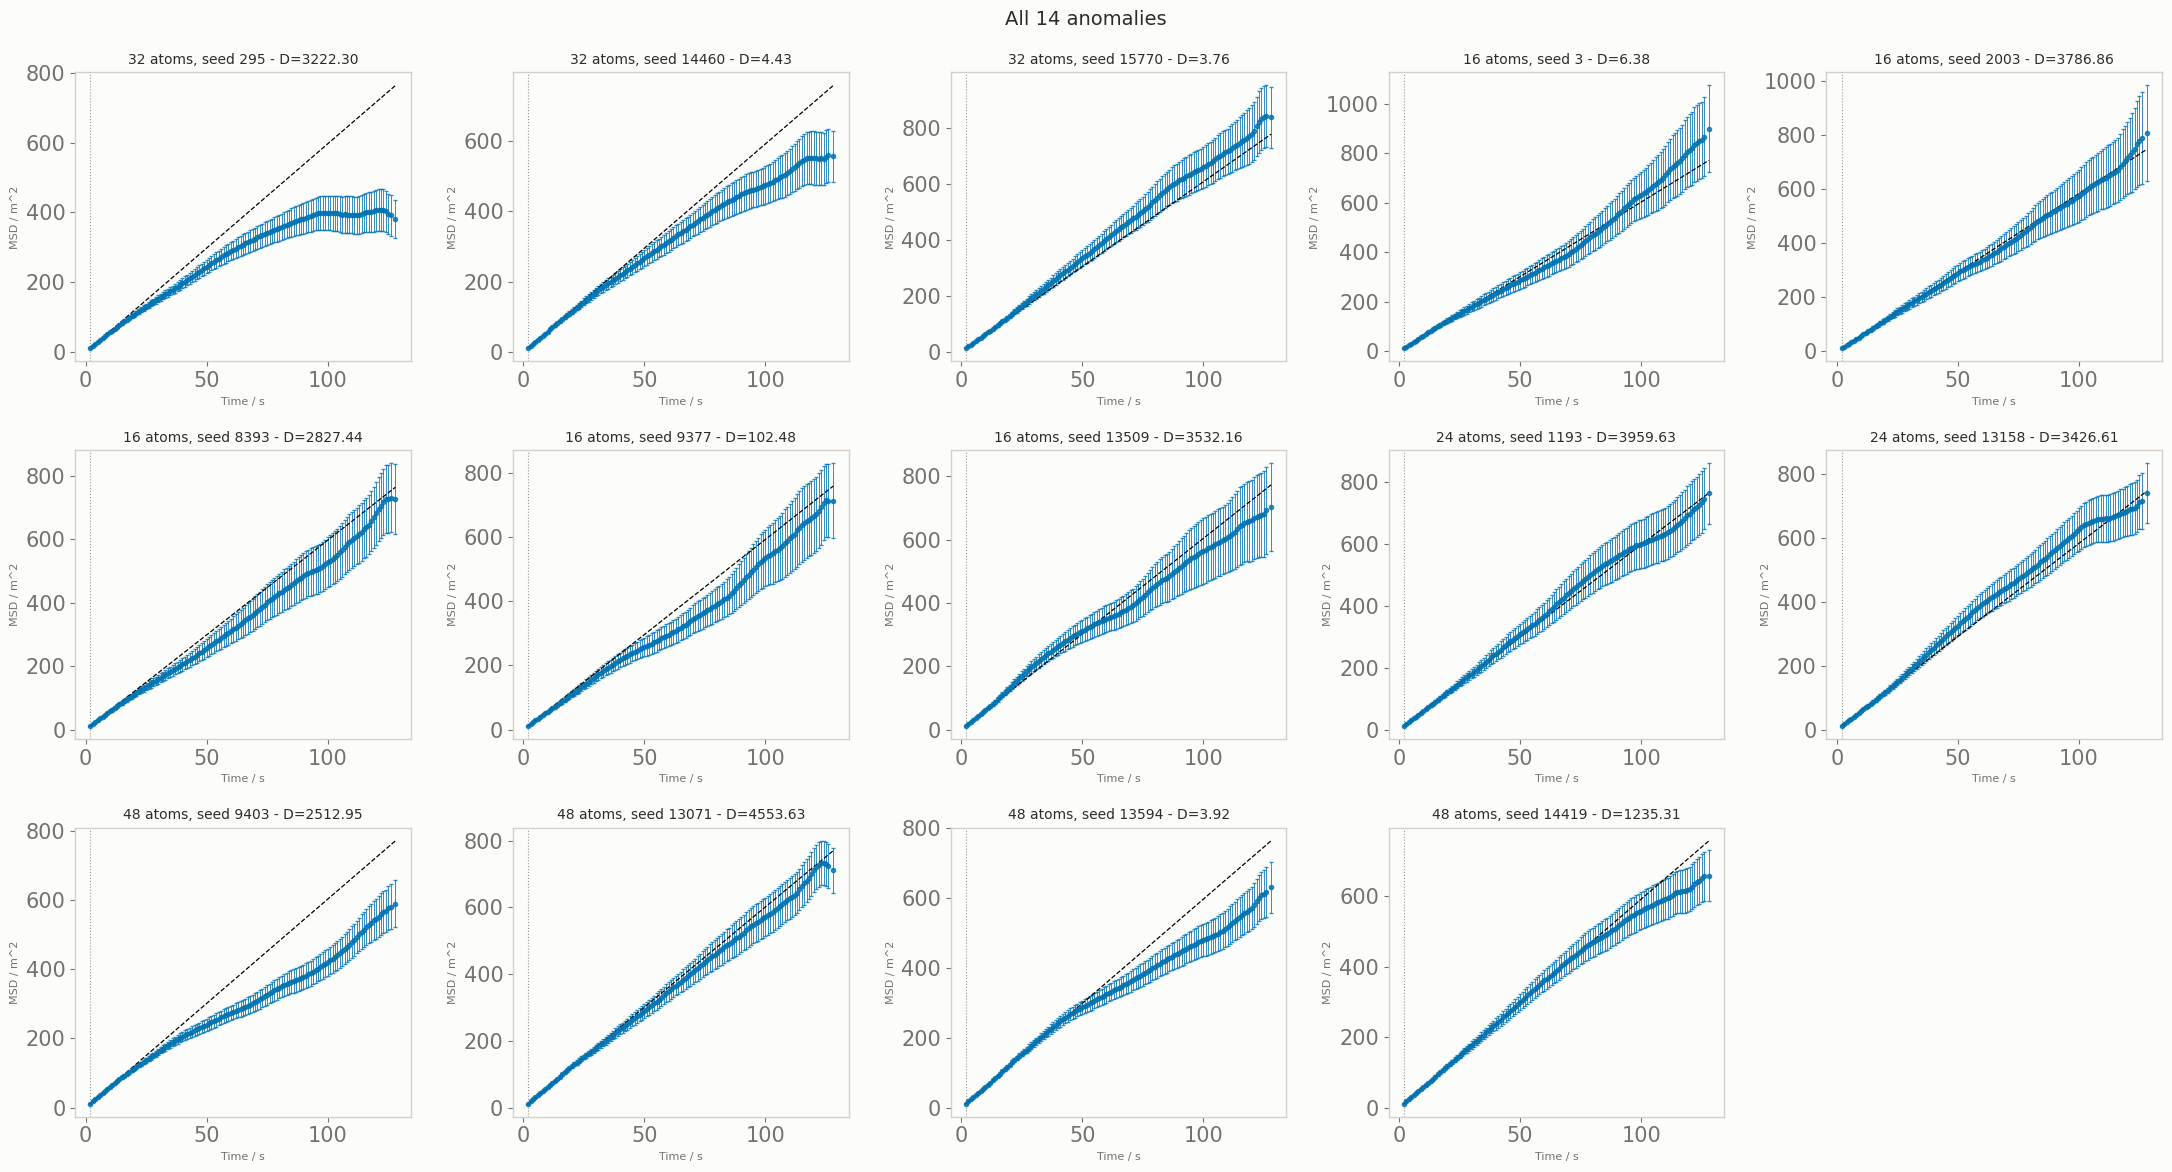

In [103]:
bad14 = [tuple(map(int, b)) for b in np.load(base / "data" / "all_bad_seeds_v2.npy")]

fig, axes = plt.subplots(3, 5, figsize=(22, 12))

axes = axes.ravel()




for k, (atoms, seed) in enumerate(bad14):

    a = build_analyzer(seed, atoms=atoms)

    t = a.dt.values

    msd = a.msd.values

    var = a.diff.dg['da'].data.variances

    err = np.sqrt(var) if var is not None else None

    regime = a.diff.diff_regime

    d_med = float(np.median(a.D.values))




    ax = axes[k]

    ax.errorbar(t, msd, yerr=err, fmt='o', ms=3, color='#0173B2',
                ecolor='#0173B2', elinewidth=0.7, capsize=1.5, alpha=0.8)
    
    ax.plot(t, msd[0] * (t / t[0]), 'k--', lw=0.9)

    ax.axvline(t[regime], color='0.6', ls=':', lw=0.8)

    ax.set_title(f'{atoms} atoms, seed {seed} - D={d_med:.2f}', fontsize=10)

    ax.set_xlabel(f'Time / {a.dt.unit}', fontsize=8)

    ax.set_ylabel(f'MSD / {a.msd.unit}', fontsize=8)



for k in range(len(bad14), len(axes)):
    axes[k].axis('off')



fig.suptitle('All 14 anomalies', fontsize=14)

plt.tight_layout()

plt.show()

In [104]:
def spectral_fingerprint(atoms, seed):
    """
    summarise where the damage sits in one matrix.

    Returns the squared components of the most negative eigenvector, its centre of
    mass along the lag axis, and how many eigenvalues are negative.


    """


    a = build_analyzer(seed, atoms=atoms)

    raw = build_raw_cov(a)

    t = a.diff.dg['da'].coords['time interval'][a.diff.diff_regime:].values




    v, vecs = np.linalg.eigh(raw)          # ascending
    weights = vecs[:, 0] ** 2              # smallest eigenvalue direction


    com = float(np.sum(np.arange(len(t)) * weights) / np.sum(weights))


    return {"atoms": atoms, "seed": seed, "n": len(v),
            "lmin": float(v[0]), "lmax": float(v[-1]),
            "n_neg": int((v < 0).sum()), "frac_neg": float((v < 0).mean()),
            "weights": weights, "t": t, "com_idx": com}



fingerprints = [spectral_fingerprint(ac, s) for ac, s in bad14]




print(f"{'atoms':>5} {'seed':>6} {'n_neg':>6} {'frac_neg':>9} {'lmin':>12} {'com_idx':>8} {'n':>4}")



for f in fingerprints:
    print(f"{f['atoms']:5d} {f['seed']:6d} {f['n_neg']:6d} {f['frac_neg']:9.3f} "
          f"{f['lmin']:12.3e} {f['com_idx']:8.1f} {f['n']:4d}")

atoms   seed  n_neg  frac_neg         lmin  com_idx    n
   32    295     23     0.183   -1.496e+03    111.4  126
   32  14460     23     0.183   -1.904e+03    121.2  126
   32  15770     11     0.087   -1.122e+03    124.0  126
   16      3      1     0.008   -8.611e+01    120.4  126
   16   2003      9     0.071   -7.834e+01     52.6  126
   16   8393     22     0.175   -9.740e+02     93.5  126
   16   9377     20     0.159   -6.480e+03    118.6  126
   16  13509     22     0.175   -2.828e+03    101.2  126
   24   1193     27     0.214   -4.750e+03    100.4  126
   24  13158     31     0.246   -2.524e+03    109.1  126
   48   9403     16     0.127   -8.710e+01     87.5  126
   48  13071     27     0.214   -5.576e+03    105.3  126
   48  13594      4     0.032   -8.730e+00    115.0  126
   48  14419     19     0.151   -5.261e+02     95.9  126


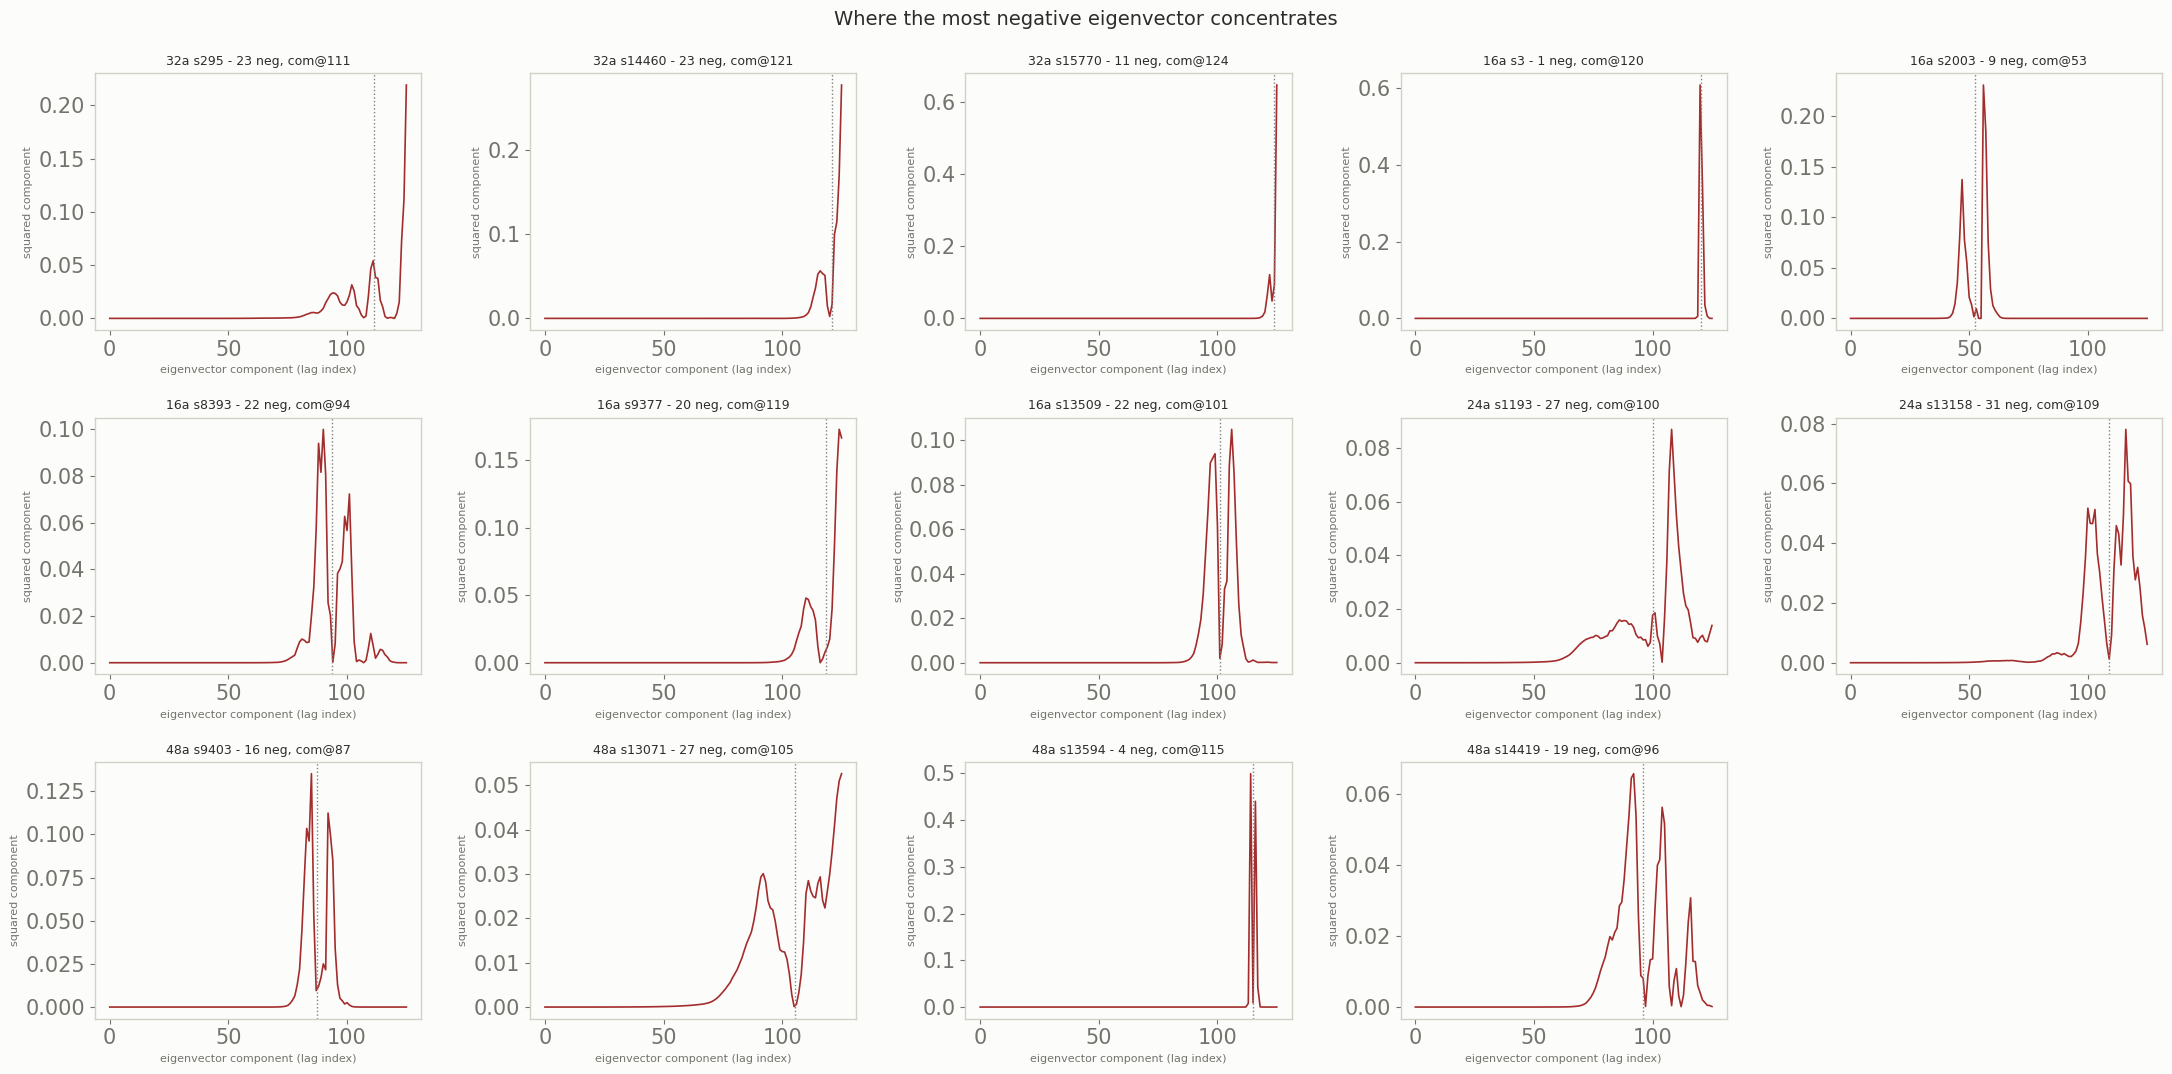

In [105]:
fig, axes = plt.subplots(3, 5, figsize=(22, 11))

axes = axes.ravel()


for k, f in enumerate(fingerprints):
    ax = axes[k]

    ax.plot(np.arange(f['n']), f['weights'], color='#a32d2d', lw=1.2)

    ax.axvline(f['com_idx'], color='0.5', ls=':', lw=1)

    ax.set_title(f"{f['atoms']}a s{f['seed']} - {f['n_neg']} neg, com@{f['com_idx']:.0f}", fontsize=9)

    ax.set_xlabel('eigenvector component (lag index)', fontsize=8)
    
    ax.set_ylabel('squared component', fontsize=8)



for k in range(len(fingerprints), len(axes)):
    axes[k].axis('off')




fig.suptitle('Where the most negative eigenvector concentrates', fontsize=14)

plt.tight_layout()

plt.savefig('anomaly_damage_location.png', dpi=150, bbox_inches='tight')

plt.show()

In [106]:
com = np.array([f['com_idx'] for f in fingerprints])

n_neg = np.array([f['n_neg'] for f in fingerprints])

n_total = np.array([f['n'] for f in fingerprints])




print("centre of mass, as a fraction along the lag axis:")

print("  ", np.round(com / n_total, 2))

print(f"  mean {np.mean(com / n_total):.2f}  std {np.std(com / n_total):.2f}")

print(f"\nnegative eigenvalues per matrix: min {n_neg.min()}, "
      f"max {n_neg.max()}, median {int(np.median(n_neg))}")

centre of mass, as a fraction along the lag axis:
   [0.88 0.96 0.98 0.96 0.42 0.74 0.94 0.8  0.8  0.87 0.69 0.84 0.91 0.76]
  mean 0.83  std 0.14

negative eigenvalues per matrix: min 1, max 31, median 21


In [107]:
araw = {(r["atoms"], r["seed"]): r["d"] for r in
        np.load(base / "data" / "anomaly_realfit_all14_v2.npy", allow_pickle=True)

        if r["method"] == "raw"}


def concentration(atoms, seed):
    """
    Inverse participation ratio of the most negative eigenvector.

    Low means the damage is concentrated in one or two components, high means it is
    spread across many.

    """


    a = build_analyzer(seed, atoms=atoms)

    v, vecs = np.linalg.eigh(build_raw_cov(a))

    p = vecs[:, 0] ** 2

    p = p / p.sum()

    return 1.0 / np.sum(p ** 2)




rows = [{"atoms": ac, "seed": s, "d_raw": araw[(ac, s)], "ipr": concentration(ac, s)}
        for ac, s in bad14]



print(f"{'atoms':>5} {'seed':>6} {'d_raw':>8} {'IPR':>7}   (low = needle, high = smeared)")
for r in sorted(rows, key=lambda x: x["ipr"]):
    print(f"{r['atoms']:5d} {r['seed']:6d} {r['d_raw']:8.3f} {r['ipr']:7.1f}")




ipr = np.array([r["ipr"] for r in rows])
d_raw = np.array([r["d_raw"] for r in rows])
rho, pval = spearmanr(ipr, d_raw)
print(f"\nspearman(IPR, d_raw) = {rho:.3f}  (p = {pval:.3f}, n = 14)")

atoms   seed    d_raw     IPR   (low = needle, high = smeared)
   16      3    0.001     2.0
   32  15770    0.000     2.2
   48  13594    0.000     2.2
   32  14460    0.000     7.0
   16   2003    0.379     7.6
   16   9377    0.010    10.1
   48   9403    0.257    12.2
   32    295    0.329    12.3
   16  13509    0.367    14.2
   16   8393    0.283    17.3
   24  13158    0.344    24.6
   48  14419    0.127    27.7
   24   1193    0.398    30.6
   48  13071    0.454    37.3

spearman(IPR, d_raw) = 0.758  (p = 0.002, n = 14)


In [108]:
def rank(x):
    """
    Rank transform, so the partial correlations below are Spearman rather than Pearson.
    
    """


    return np.argsort(np.argsort(x)).astype(float)




def partial_spearman(x, y, control):
    """
    
    Spearman correlation between x and y after removing the influence of control.
    
    """


    rx, ry, rc = rank(x), rank(y), rank(control)


    def resid(target, c):
        design = np.column_stack([np.ones_like(c), c])
        return target - design @ np.linalg.lstsq(design, target, rcond=None)[0]


    return np.corrcoef(resid(rx, rc), resid(ry, rc))[0, 1]




def ipr_and_lmin(atoms, seed):
    """
    Concentration, smallest eigenvalue and negative count for one matrix.
    
    """


    a = build_analyzer(seed, atoms=atoms)

    v, vecs = np.linalg.eigh(build_raw_cov(a))

    p = vecs[:, 0] ** 2

    p = p / p.sum()

    return 1.0 / np.sum(p ** 2), float(v[0]), int((v < 0).sum())


rows = []

for ac, s in bad14:
    ipr_val, lmin_val, n_neg_val = ipr_and_lmin(ac, s)
    
    rows.append({"atoms": ac, "seed": s, "d": araw[(ac, s)],
                 "ipr": ipr_val, "lmin": lmin_val, "nneg": n_neg_val})

    

ipr = np.array([r["ipr"] for r in rows])

d = np.array([r["d"] for r in rows])

lmin = np.array([r["lmin"] for r in rows])

n_neg = np.array([r["nneg"] for r in rows])

atoms_arr = np.array([r["atoms"] for r in rows])



print("plain Spearman against severity:")

for name, x in [("IPR", ipr), ("|lmin|", np.abs(lmin)), ("n_neg", n_neg)]:
    r, p = spearmanr(x, d)

    print(f"  {name:8s} rho={r:+.3f}  p={p:.3f}")



print(f"\nIPR vs |lmin|: rho={spearmanr(ipr, np.abs(lmin))[0]:+.3f}")



print("\npartial correlations:")

print(f"  IPR vs d, controlling |lmin| : {partial_spearman(ipr, d, np.abs(lmin)):+.3f}")

print(f"  IPR vs d, controlling n_neg  : {partial_spearman(ipr, d, n_neg):+.3f}")

print(f"  |lmin| vs d, controlling IPR : {partial_spearman(np.abs(lmin), d, ipr):+.3f}")

plain Spearman against severity:
  IPR      rho=+0.758  p=0.002
  |lmin|   rho=+0.429  p=0.126
  n_neg    rho=+0.589  p=0.027

IPR vs |lmin|: rho=+0.534

partial correlations:
  IPR vs d, controlling |lmin| : +0.693
  IPR vs d, controlling n_neg  : +0.598
  |lmin| vs d, controlling IPR : +0.043


In [109]:
print(f"IPR vs d, plain                   : {spearmanr(ipr, d)[0]:+.3f}")

print(f"IPR vs d, controlling |lmin|      : {partial_spearman(ipr, d, np.abs(lmin)):+.3f}")

print(f"IPR vs d, controlling system size : {partial_spearman(ipr, d, atoms_arr.astype(float)):+.3f}")

print(f"IPR vs system size                : {spearmanr(ipr, atoms_arr)[0]:+.3f}")




print("\nwithin each system size:")

for ac in [16, 24, 32, 48]:
    m = atoms_arr == ac
    if m.sum() >= 3:
        print(f"  {ac:2d} atoms (n={m.sum()}): rho={spearmanr(ipr[m], d[m])[0]:+.3f}")
    else:
        print(f"  {ac:2d} atoms (n={m.sum()}): too few to rank")



loo = [spearmanr(np.delete(ipr, k), np.delete(d, k))[0] for k in range(len(ipr))]
print(f"\nleave one out range: {min(loo):+.3f} to {max(loo):+.3f}")


worst = int(np.argmax(np.abs(np.array(loo) - spearmanr(ipr, d)[0])))
print(f"most influential point: {rows[worst]['atoms']} atoms, seed {rows[worst]['seed']}")

IPR vs d, plain                   : +0.758
IPR vs d, controlling |lmin|      : +0.693
IPR vs d, controlling system size : +0.849
IPR vs system size                : +0.172

within each system size:
  16 atoms (n=5): rho=+0.300
  24 atoms (n=2): too few to rank
  32 atoms (n=3): rho=+1.000
  48 atoms (n=4): rho=+0.800

leave one out range: +0.698 to +0.852
most influential point: 16 atoms, seed 2003


anomaly IPR: min 2.0  median 12.3  max 37.3
healthy IPR: min 1.2  median 6.7  max 63.4


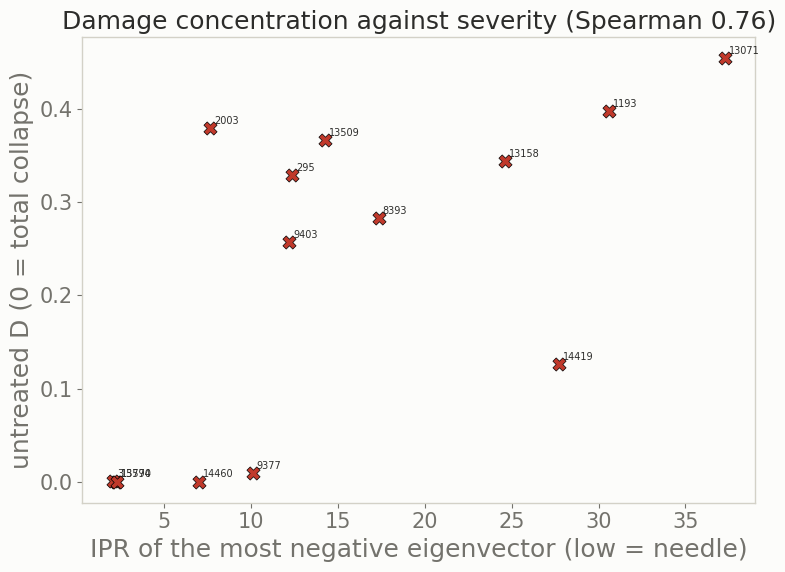

In [110]:
bad_set = set(bad14)

healthy_ipr = []

for ac in [16, 24, 32, 48]:
    found, s = 0, 0

    while found < 40:
        if (ac, s) not in bad_set:
            healthy_ipr.append(concentration(ac, s))
            found += 1
        s += 1


healthy_ipr = np.array(healthy_ipr)



print(f"anomaly IPR: min {ipr.min():.1f}  median {np.median(ipr):.1f}  max {ipr.max():.1f}")

print(f"healthy IPR: min {healthy_ipr.min():.1f}  median {np.median(healthy_ipr):.1f}  "
      f"max {healthy_ipr.max():.1f}")

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(ipr, d, s=90, marker='X', c='#c0392b', edgecolor='k', lw=0.5, zorder=5)

for r in rows:
    ax.annotate(f"{r['seed']}", (r['ipr'], r['d']), fontsize=7,
                xytext=(3, 3), textcoords='offset points')
    
ax.set_xlabel('IPR of the most negative eigenvector (low = needle)')

ax.set_ylabel('untreated D (0 = total collapse)')

ax.set_title(f'Damage concentration against severity (Spearman {spearmanr(ipr, d)[0]:.2f})')

plt.tight_layout()

plt.show()

In [111]:
def slope_leverage(a):

    """
    Unit vector along the slope direction of the GLS design.

    This is the time column orthogonalised against the intercept, which is what the
    slope estimate actually loads on. Using raw or de-meaned time gives the wrong
    direction.


    """


    t = a.diff.dg['da'].coords['time interval'][a.diff.diff_regime:].values.astype(float)
    ones = np.ones_like(t)
    orthogonal = t - ones * (t @ ones) / (ones @ ones)
    return orthogonal / np.linalg.norm(orthogonal)





def alignment_g(atoms, seed):

    """
    Overlap of the negative eigen directions with the slope direction.
    
    """
    
    a = build_analyzer(seed, atoms=atoms)

    v, vecs = np.linalg.eigh(build_raw_cov(a))

    xhat = slope_leverage(a)

    negative = v < 0

    if not negative.any():
        return 0.0, 0
    proj = (vecs[:, negative].T @ xhat) ** 2
    return float(np.sum(proj / np.abs(v[negative]))), int(negative.sum())



g_anom = []
for ac, s in bad14:
    g_val, n_neg_val = alignment_g(ac, s)
    g_anom.append({"atoms": ac, "seed": s, "G": g_val, "n_neg": n_neg_val})



g_healthy = []
for ac in [16, 24, 32, 48]:
    found, s = 0, 0
    while found < 60:
        if (ac, s) not in bad_set:
            g_val, n_neg_val = alignment_g(ac, s)
            g_healthy.append({"atoms": ac, "seed": s, "G": g_val, "n_neg": n_neg_val})
            found += 1
        s += 1



g_a = np.array([r["G"] for r in g_anom])

g_h = np.array([r["G"] for r in g_healthy])


print(f"anomaly G: min {g_a.min():.3e}  median {np.median(g_a):.3e}  max {g_a.max():.3e}")

print(f"healthy G: min {g_h.min():.3e}  median {np.median(g_h):.3e}  max {g_h.max():.3e}")

print("\nper system size, anomaly range against healthy maximum:")


for ac in [16, 24, 32, 48]:
    anom_vals = [r["G"] for r in g_anom if r["atoms"] == ac]
    healthy_vals = [r["G"] for r in g_healthy if r["atoms"] == ac]
    if anom_vals:
        verdict = 'separated' if min(anom_vals) > max(healthy_vals) else 'OVERLAP'
        print(f"  {ac:2d} atoms: [{min(anom_vals):.2e}, {max(anom_vals):.2e}] "
              f"vs {max(healthy_vals):.2e}  -> {verdict}")

anomaly G: min 3.377e-08  median 7.543e-05  max 2.642e-04
healthy G: min 0.000e+00  median 5.633e-06  max 6.314e-04

per system size, anomaly range against healthy maximum:
  16 atoms: [3.38e-08, 1.63e-04] vs 3.75e-04  -> OVERLAP
  24 atoms: [8.04e-05, 1.04e-04] vs 3.38e-04  -> OVERLAP
  32 atoms: [1.33e-05, 7.04e-05] vs 6.31e-04  -> OVERLAP
  48 atoms: [1.12e-05, 2.64e-04] vs 1.27e-04  -> OVERLAP


In [112]:
# threshold trained on three sizes, tested on the fourth

for held in [16, 24, 32, 48]:
    train_a = np.array([r["G"] for r in g_anom if r["atoms"] != held])

    train_h = np.array([r["G"] for r in g_healthy if r["atoms"] != held])

    test_a = np.array([r["G"] for r in g_anom if r["atoms"] == held])

    test_h = np.array([r["G"] for r in g_healthy if r["atoms"] == held])

    threshold = (train_a.min() + train_h.max()) / 2


    if len(test_a):
        sens = np.mean(test_a > threshold)

        fpr = np.mean(test_h > threshold)
        
        print(f"hold out {held:2d}: threshold={threshold:.2e}  sens={sens:.0%}  FPR={fpr:.0%}")

hold out 16: threshold=3.21e-04  sens=0%  FPR=3%
hold out 24: threshold=3.16e-04  sens=0%  FPR=2%
hold out 32: threshold=1.87e-04  sens=0%  FPR=3%
hold out 48: threshold=3.16e-04  sens=0%  FPR=0%


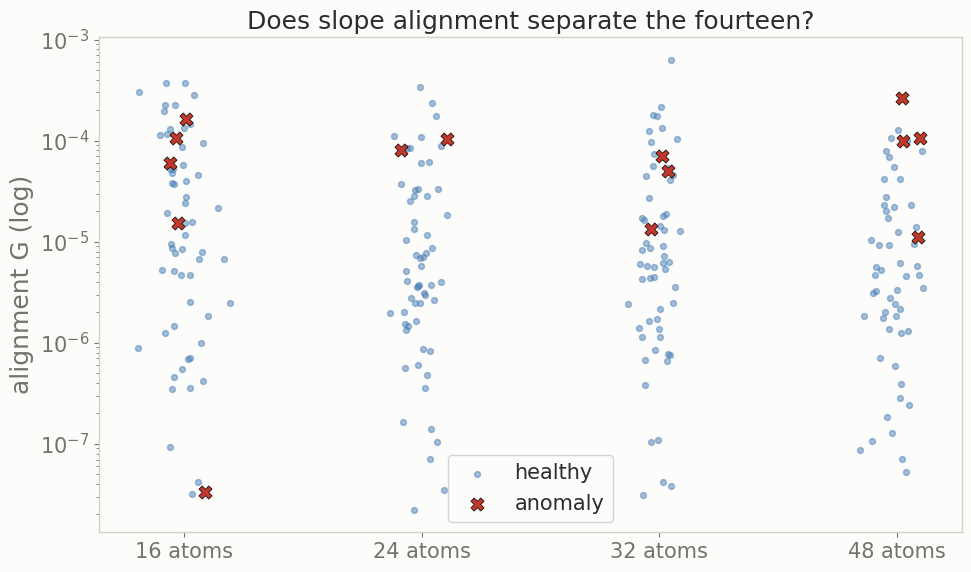

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))

sizes = [16, 24, 32, 48]

for i, ac in enumerate(sizes):
    healthy_vals = [r["G"] for r in g_healthy if r["atoms"] == ac and r["G"] > 0]

    anom_vals = [r["G"] for r in g_anom if r["atoms"] == ac and r["G"] > 0]

    ax.scatter(np.random.normal(i, 0.06, len(healthy_vals)), healthy_vals,
               s=18, c='#4a7fb5', alpha=0.5, label='healthy' if i == 0 else None)
    
    ax.scatter(np.random.normal(i, 0.06, len(anom_vals)), anom_vals,
               s=90, marker='X', c='#c0392b', edgecolor='k', lw=0.5,
               label='anomaly' if i == 0 else None, zorder=5)
    
ax.set_yscale('log')

ax.set_xticks(range(len(sizes)))

ax.set_xticklabels([f'{a} atoms' for a in sizes])

ax.set_ylabel('alignment G (log)')

ax.set_title('Does slope alignment separate the fourteen?')

ax.legend()

plt.tight_layout()

plt.savefig('alignment_G_separation.png', dpi=150, bbox_inches='tight')

plt.show()

/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


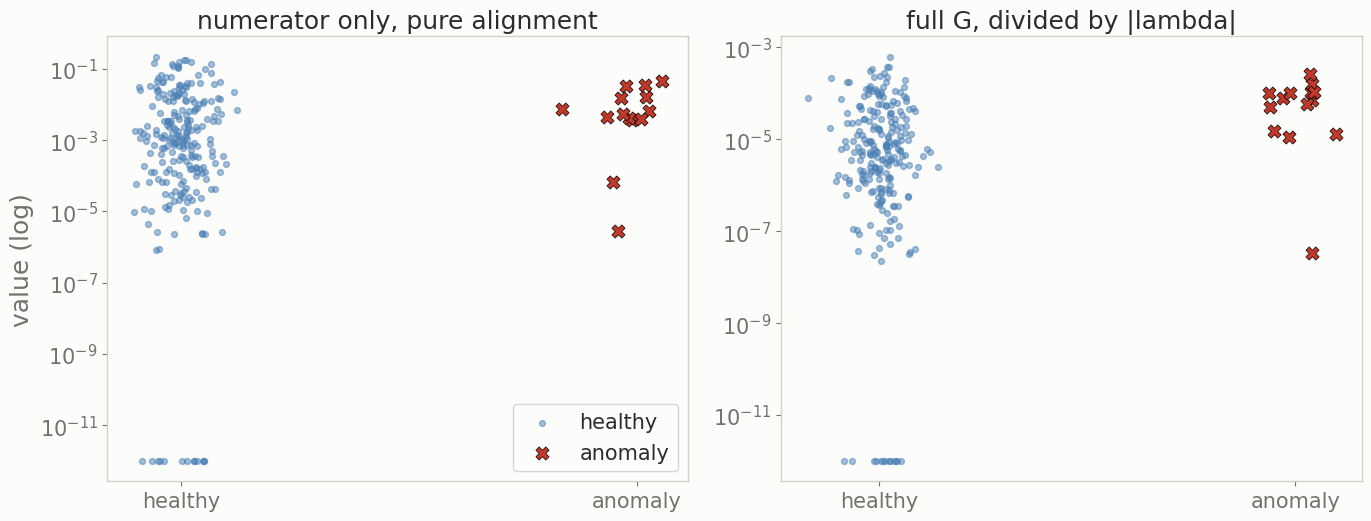

In [114]:
def alignment_parts(atoms, seed):
    """
    Return the numerator alone and the full G, to see which one carries any signal.
    
    """


    a = build_analyzer(seed, atoms=atoms)

    v, vecs = np.linalg.eigh(build_raw_cov(a))

    xhat = slope_leverage(a)

    negative = v < 0

    if not negative.any():
        return 0.0, 0.0
    
    proj = (vecs[:, negative].T @ xhat) ** 2

    return float(proj.sum()), float(np.sum(proj / np.abs(v[negative])))


parts_anom = np.array([alignment_parts(ac, s) for ac, s in bad14])

parts_healthy = np.array([alignment_parts(r["atoms"], r["seed"]) for r in g_healthy])




fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

titles = ['numerator only, pure alignment', 'full G, divided by |lambda|']

for ax, col, title in zip(axes, [0, 1], titles):

    ax.scatter(np.random.normal(0, .05, len(parts_healthy)),
               np.maximum(parts_healthy[:, col], 1e-12),
               s=18, c='#4a7fb5', alpha=0.5, label='healthy')

    ax.scatter(np.random.normal(1, .05, len(parts_anom)),
               np.maximum(parts_anom[:, col], 1e-12),
               s=90, marker='X', c='#c0392b', edgecolor='k', lw=0.5, label='anomaly', zorder=5)

    ax.set_yscale('log')

    ax.set_xticks([0, 1])

    ax.set_xticklabels(['healthy', 'anomaly'])

    ax.set_title(title)

axes[0].set_ylabel('value (log)')

axes[0].legend()

plt.tight_layout()

plt.savefig('alignment_control.png', dpi=150, bbox_inches='tight')

plt.show()

/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


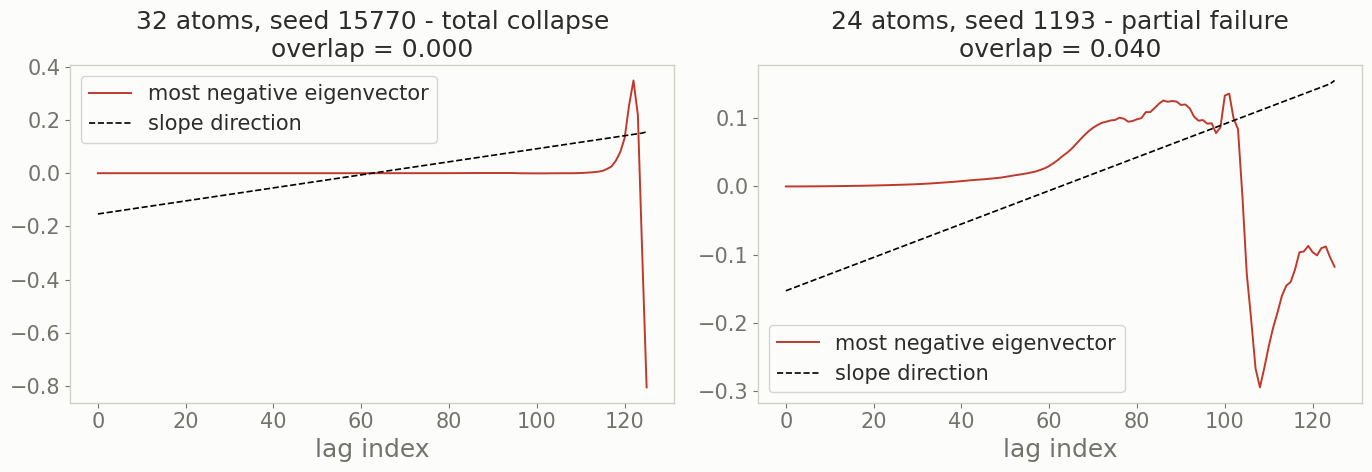

In [115]:
# what the two ends of the severity range actually look like

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (atoms, seed, label) in zip(axes, [(32, 15770, 'total collapse'),
                                           (24, 1193, 'partial failure')]):
    a = build_analyzer(seed, atoms=atoms)
    v, vecs = np.linalg.eigh(build_raw_cov(a))
    xhat = slope_leverage(a)
    overlap = (vecs[:, 0] @ xhat) ** 2



    ax.plot(vecs[:, 0], color='#c0392b', lw=1.4, label='most negative eigenvector')

    ax.plot(xhat, color='k', lw=1.2, ls='--', label='slope direction')


    ax.set_title(f'{atoms} atoms, seed {seed} - {label}\noverlap = {overlap:.3f}')

    ax.set_xlabel('lag index')

    ax.legend()


plt.tight_layout()
plt.show()

In [116]:
detector = list(np.load(base / "data" / "detector_healthy.npy", allow_pickle=True))

print("keys stored per record:", sorted(detector[0].keys()))

print("first record:", detector[0])




all14 = list(np.load(base / "data" / "anomaly_realfit_all14_v2.npy", allow_pickle=True))

anomaly_ratio = {(r["atoms"], r["seed"]): r["d"] / r["d_ols"]
                 for r in all14 if r["method"] == "raw" and np.isfinite(r["d"])}



# the healthy file may store the ratio directly, or the two fits it is built from
sample = detector[0]
numerator = next((k for k in ("d_raw", "d", "d_bayes", "d_post") if k in sample), None)
denominator = next((k for k in ("d_ols", "ols", "d_lin") if k in sample), None)



healthy_ratio = {}
for r in detector:
    if "ratio" in r and np.isfinite(r["ratio"]):
        healthy_ratio[(r["atoms"], r["seed"])] = float(r["ratio"])
    elif numerator and denominator:
        num, den = r.get(numerator), r.get(denominator)
        if num is not None and den not in (None, 0) and np.isfinite(num) and np.isfinite(den):
            healthy_ratio[(r["atoms"], r["seed"])] = float(num) / float(den)

print(f"\nusing: {'stored ratio' if 'ratio' in sample else f'{numerator} / {denominator}'}")

print(f"healthy ratios recovered: {len(healthy_ratio)} of {len(detector)}")



if not healthy_ratio:
    raise SystemExit("could not build the ratio - check the key names printed above")



h_vals = np.array(list(healthy_ratio.values()))

a_vals = np.array(list(anomaly_ratio.values()))


print(f"\nhealthy  n={len(h_vals)}  median {np.median(h_vals):.3f}  min {h_vals.min():.3f}")

print(f"anomaly  n={len(a_vals)}  median {np.median(a_vals):.3f}  max {a_vals.max():.3f}")

print(f"clean gap: {a_vals.max() < h_vals.min()}  "
      f"(anomaly max {a_vals.max():.3f} vs healthy min {h_vals.min():.3f})")


print("\nthreshold  sensitivity  false alarms")

for thr in [0.5, 0.6, 0.7]:
    print(f"  {thr:<9} {np.mean(a_vals < thr):>10.0%} {np.mean(h_vals < thr):>13.1%}")


n_warned = sum(1 for r in detector if r.get("warned"))

print(f"\nslogdet warning fired on {n_warned} of {len(detector)} healthy fits")

keys stored per record: ['atoms', 'd_ols', 'd_raw', 'seed', 'warned']
first record: {'atoms': 16, 'seed': 0, 'd_ols': 0.7654362225603957, 'd_raw': 0.9769467730274508, 'warned': True}

using: d_raw / d_ols
healthy ratios recovered: 400 of 400

healthy  n=400  median 1.009  min 0.623
anomaly  n=14  median 0.328  max 0.604
clean gap: True  (anomaly max 0.604 vs healthy min 0.623)

threshold  sensitivity  false alarms
  0.5              93%          0.0%
  0.6              93%          0.0%
  0.7             100%          1.5%

slogdet warning fired on 400 of 400 healthy fits


In [117]:
# within each system size, then a threshold trained on three sizes and tested on the fourth

print("within system size (anomaly max against healthy min):")

for ac in [16, 24, 32, 48]:
    a_here = [v for (atoms, _), v in anomaly_ratio.items() if atoms == ac]

    h_here = [v for (atoms, _), v in healthy_ratio.items() if atoms == ac]

    if a_here and h_here:
        verdict = "separated" if max(a_here) < min(h_here) else "OVERLAP"

        print(f"  {ac:2d} atoms: {max(a_here):.3f} vs {min(h_here):.3f}  >>> {verdict}")



print("\nhold one system size out:")

for held in [16, 24, 32, 48]:
    train_a = [v for (atoms, _), v in anomaly_ratio.items() if atoms != held]

    train_h = [v for (atoms, _), v in healthy_ratio.items() if atoms != held]

    test_a = [v for (atoms, _), v in anomaly_ratio.items() if atoms == held]

    test_h = [v for (atoms, _), v in healthy_ratio.items() if atoms == held]

    if not test_a:
        continue
    threshold = (max(train_a) + min(train_h)) / 2

    sens = np.mean(np.array(test_a) < threshold)

    fpr = np.mean(np.array(test_h) < threshold)

    print(f"  hold out {held:2d}: threshold={threshold:.3f}  sensitivity={sens:.0%}  "
          f"false alarms={fpr:.1%}")

within system size (anomaly max against healthy min):
  16 atoms: 0.414 vs 0.623  >>> separated
  24 atoms: 0.405 vs 0.688  >>> separated
  32 atoms: 0.604 vs 0.686  >>> separated
  48 atoms: 0.475 vs 0.759  >>> separated

hold one system size out:
  hold out 16: threshold=0.645  sensitivity=100%  false alarms=1.0%
  hold out 24: threshold=0.613  sensitivity=100%  false alarms=0.0%
  hold out 32: threshold=0.549  sensitivity=67%  false alarms=0.0%
  hold out 48: threshold=0.613  sensitivity=100%  false alarms=0.0%


In [118]:
sweep = list(np.load(base / "data" / "anomaly_realfit_c_sweep.npy", allow_pickle=True))

c_values = [0.05, 0.10, 0.25, 0.50, 1.00, 2.00]


print(f"{'c':>6} {'median D':>10} {'median d_std':>14} {'recovered':>11}")

for c in c_values:
    d_c = np.array([r["d"] for r in sweep if r["c"] == c and np.isfinite(r["d"])])

    s_c = np.array([r["d_std"] for r in sweep if r["c"] == c and np.isfinite(r["d_std"])])

    recovered = np.mean((d_c > 0.5) & (d_c < 2.0)) if d_c.size else np.nan
    
    print(f"{c:>6} {np.median(d_c):>10.3f} {np.median(s_c):>14.4f} {recovered:>10.0%}")

     c   median D   median d_std   recovered
  0.05      0.836         0.0709        93%
   0.1      0.850         0.0767        93%
  0.25      0.849         0.0833       100%
   0.5      0.892         0.0893       100%
   1.0      0.925         0.0971       100%
   2.0      0.929         0.1057       100%


In [119]:
import kinisi

from ase.io import read

from MDAnalysis import Universe


path = os.path.join(os.path.dirname(kinisi.__file__), 'tests/inputs/LiPS.exyz')

frames = read(path, format='extxyz', index=':')

cell_dims = [[*f.cell.lengths(), *f.cell.angles()] for f in frames]



u = Universe(path, path, format='XYZ', topology_format='XYZ', dt=20.0 / 1000)

for ts, dims in zip(u.trajectory, cell_dims):
    ts.dimensions = dims



a_lips = DiffusionAnalyzer.from_universe(u, specie='LI', time_step=0.001 * sc.Unit('ps'),
    step_skip=20 * sc.units.dimensionless, progress=False)

a_lips.diffusion(1.5 * sc.Unit('ps'))


print("diff_regime:", a_lips.diff.diff_regime)


print("dt unit:", a_lips.dt.unit, " start:", a_lips.dt.values[0], " stop:", a_lips.dt.values[-1])

print("covariance shape:", a_lips.diff.covariance_matrix.values.shape)

Likelihood Sampling: 100%|██████████| 1500/1500 [00:00<00:00, 5612.18it/s]

diff_regime: 74
dt unit: ps  start: 0.02  stop: 4.0
covariance shape: (126, 126)


In [120]:
kinisi_cov = a_lips.diff.covariance_matrix.values

raw_lips = build_raw_cov(a_lips)


print("kinisi stored cov:", kinisi_cov.shape, " build_raw_cov:", raw_lips.shape)


if kinisi_cov.shape == raw_lips.shape:

    relative = np.abs(kinisi_cov - raw_lips) / (np.abs(kinisi_cov) + 1e-30)

    print(f"max relative difference   : {np.nanmax(relative):.3e}")

    print(f"median relative difference: {np.nanmedian(relative):.3e}")

    print(f"kinisi stored lmin: {np.linalg.eigvalsh(kinisi_cov).min():.3e}  (>= 0 if reconditioned)")

    print(f"rebuilt raw lmin  : {np.linalg.eigvalsh(raw_lips).min():.3e}  (< 0 expected)")

else:
    print("shape mismatch - build_raw_cov is not reconstructing the matrix kinisi uses here")

kinisi stored cov: (126, 126)  build_raw_cov: (126, 126)
max relative difference   : 4.493e-02
median relative difference: 2.013e-02
kinisi stored lmin: -1.228e-17  (>= 0 if reconditioned)
rebuilt raw lmin  : -3.471e-03  (< 0 expected)


In [121]:
swap = list(np.load(base / "data" / "eigen_swap_test.npy", allow_pickle=True))

controls = [(16, 0), (24, 0), (32, 0), (48, 0)]

order = bad14 + controls


columns = ["raw", "trueval_empvec", "trueval_empvec_scaled", "empval_truevec"]

headers = ["raw", "model lambda + emp U", "same, scaled", "emp lambda + model U"]

print(f"{'atoms':>5} {'seed':>6} " + " ".join(f"{h:>21}" for h in headers))

for atoms, seed in order:
    group = {r["method"]: r for r in swap if r["atoms"] == atoms and r["seed"] == seed}

    vals = " ".join(f"{group[c]['d']:21.3f}" if c in group and np.isfinite(group[c]["d"])
                    else f"{'nan':>21}" for c in columns)
    
    tag = "control" if seed == 0 else ""

    print(f"{atoms:5d} {seed:6d} {vals}  {tag}")

atoms   seed                   raw  model lambda + emp U          same, scaled  emp lambda + model U
   32    295                 0.325                 0.000                 0.000                 0.923  
   32  14460                 0.000                 0.000                 0.000                 0.987  
   32  15770                 0.000                 0.000                 0.000                 1.045  
   16      3                 0.001                 1.036                 1.033                 0.999  
   16   2003                 0.379                 0.003                 0.002                 0.941  
   16   8393                 0.282                 1.133                 1.129                 0.910  
   16   9377                 0.010                 5.846                 5.842                 0.964  
   16  13509                 0.369                 0.001                 0.001                 1.022  
   24   1193                 0.397                 0.001                 0.

In [122]:
surgical = list(np.load(base / "data" / "surgical_swap_test.npy", allow_pickle=True))

columns = ["raw", "surgical_evec", "negatives_only_val"]

headers = ["raw", "swap one eigenvector", "negatives only"]


print(f"{'atoms':>5} {'seed':>6} " + " ".join(f"{h:>21}" for h in headers))


for atoms, seed in order:
    group = {r["method"]: r for r in surgical if r["atoms"] == atoms and r["seed"] == seed}

    vals = " ".join(f"{group[c]['d']:21.3f}" if c in group and np.isfinite(group[c]["d"])
                    else f"{'nan':>21}" for c in columns)
    
    tag = "control" if seed == 0 else ""

    print(f"{atoms:5d} {seed:6d} {vals}  {tag}")

atoms   seed                   raw  swap one eigenvector        negatives only
   32    295                 0.327                 0.809                 0.000  
   32  14460                 0.000                 0.663                 0.000  
   32  15770                 0.000                 0.755                 0.000  
   16      3                 0.001                 0.703                 0.001  
   16   2003                 0.377                 0.900                 0.000  
   16   8393                 0.282                 0.853                 0.953  
   16   9377                 0.011                 0.806                 6.946  
   16  13509                 0.363                 0.975                 0.000  
   24   1193                 0.397                 0.957                 0.000  
   24  13158                 0.347                 0.946                 0.000  
   48   9403                 0.255                 0.853                 0.000  
   48  13071                 0

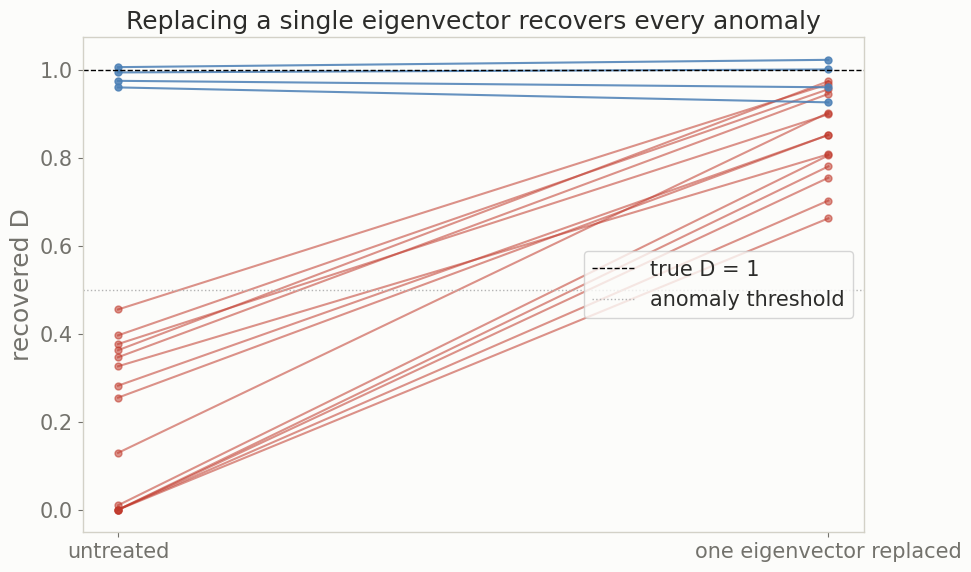

In [123]:
fig, ax = plt.subplots(figsize=(10, 6))

for atoms, seed in bad14:
    group = {r["method"]: r["d"] for r in surgical
             if r["atoms"] == atoms and r["seed"] == seed}
    if "raw" in group and "surgical_evec" in group:
        ax.plot([0, 1], [group["raw"], group["surgical_evec"]],
                'o-', color='#c0392b', alpha=0.55, ms=5)
        
for atoms, seed in controls:
    group = {r["method"]: r["d"] for r in surgical
             if r["atoms"] == atoms and r["seed"] == seed}
    if "raw" in group and "surgical_evec" in group:
        ax.plot([0, 1], [group["raw"], group["surgical_evec"]],
                'o-', color='#4a7fb5', alpha=0.85, ms=5)



ax.axhline(1.0, color='k', ls='--', lw=1, label='true D = 1')

ax.axhline(0.5, color='0.7', ls=':', lw=1, label='anomaly threshold')

ax.set_xticks([0, 1])

ax.set_xticklabels(['untreated', 'one eigenvector replaced'])

ax.set_ylabel('recovered D')

ax.set_title('Replacing a single eigenvector recovers every anomaly')

ax.legend(loc='center right')

plt.tight_layout()

plt.savefig('surgical_swap_paired.png', dpi=150, bbox_inches='tight')

plt.show()

In [124]:
vrep = list(np.load(base / "data" / "variance_repair_test.npy", allow_pickle=True))

methods = ["raw", "floor", "parametric", "shrink", "spec_cont"]


print(f"{'atoms':>5} {'seed':>6} " + " ".join(f"{m:>11}" for m in methods))

for atoms, seed in order:
    group = {r["method"]: r for r in vrep if r["atoms"] == atoms and r["seed"] == seed}
    vals = " ".join(f"{group[m]['d']:11.3f}" if m in group and np.isfinite(group[m]["d"])
                    else f"{'nan':>11}" for m in methods)
    tag = "control" if seed == 0 else ""
    print(f"{atoms:5d} {seed:6d} {vals}  {tag}")



print("\nsummary over the fourteen anomalies")


bad_set = set(bad14)

for m in methods:
    d_vals = np.array([r["d"] for r in vrep if r["method"] == m
                       and np.isfinite(r["d"]) and (r["atoms"], r["seed"]) in bad_set])
    
    s_vals = np.array([r["d_std"] for r in vrep if r["method"] == m
                       and np.isfinite(r["d_std"]) and (r["atoms"], r["seed"]) in bad_set])
    
    recovered = np.mean((d_vals > 0.5) & (d_vals < 2.0)) if d_vals.size else np.nan
    
    print(f"  {m:11s} median D {np.median(d_vals):6.3f}   "
          f"median d_std {np.median(s_vals):7.4f}   recovered {recovered:4.0%}")

atoms   seed         raw       floor  parametric      shrink   spec_cont
   32    295       0.327       0.581       0.953       0.942       0.000  
   32  14460       0.000       0.840       0.974       0.971       0.000  
   32  15770       0.000       1.045       1.047       1.047       0.000  
   16      3       0.001       1.039       1.013       1.012       0.001  
   16   2003       0.379       0.895       0.942       0.935       0.000  
   16   8393       0.282       0.860       0.986       0.981       1.759  
   16   9377       0.011       0.823       0.950       0.946      12.121  
   16  13509       0.365       0.943       1.016       1.011       0.000  
   24   1193       0.396       0.830       1.008       1.006       0.000  
   24  13158       0.348       0.821       0.952       0.947       0.000  
   48   9403       0.254       0.817       1.005       0.997       0.000  
   48  13071       0.454       0.975       1.032       1.032       3.150  
   48  13594       0.000   

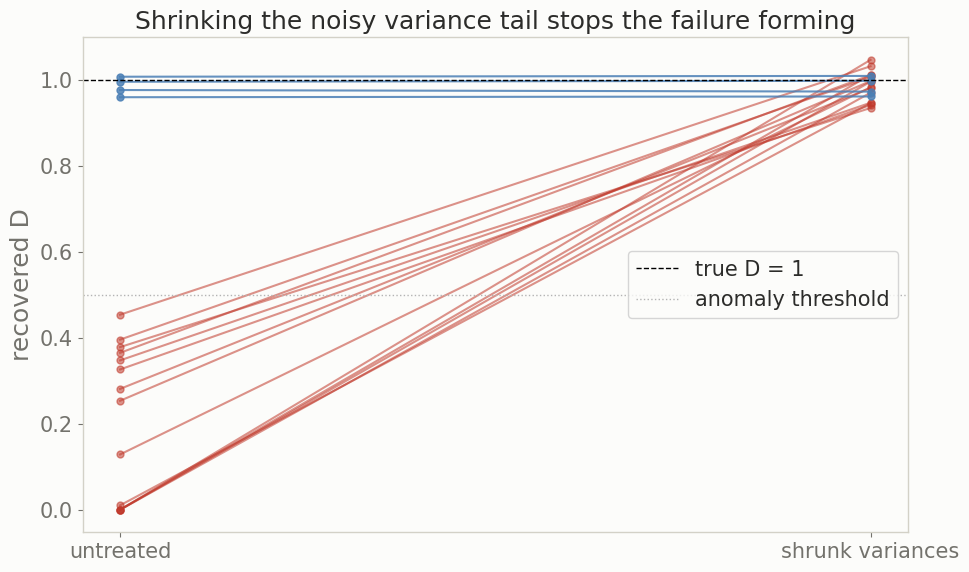

In [125]:
fig, ax = plt.subplots(figsize=(10, 6))

for atoms, seed in bad14:
    group = {r["method"]: r["d"] for r in vrep if r["atoms"] == atoms and r["seed"] == seed}

    if "raw" in group and "shrink" in group:
        ax.plot([0, 1], [group["raw"], group["shrink"]], 'o-', color='#c0392b', alpha=0.55, ms=5)

for atoms, seed in controls:
    group = {r["method"]: r["d"] for r in vrep if r["atoms"] == atoms and r["seed"] == seed}

    if "raw" in group and "shrink" in group:
        ax.plot([0, 1], [group["raw"], group["shrink"]], 'o-', color='#4a7fb5', alpha=0.85, ms=5)



ax.axhline(1.0, color='k', ls='--', lw=1, label='true D = 1')

ax.axhline(0.5, color='0.7', ls=':', lw=1, label='anomaly threshold')

ax.set_xticks([0, 1])

ax.set_xticklabels(['untreated', 'shrunk variances'])

ax.set_ylabel('recovered D')

ax.set_title('Shrinking the noisy variance tail stops the failure forming')

ax.legend(loc='center right')

plt.tight_layout()

plt.show()

In [126]:
coverage = list(np.load(base / "data" / "shrink_coverage.npy", allow_pickle=True))

print("coverage over 1000 healthy 32 atom seeds (nominal 50 / 68 / 95)")

for method in ("raw", "shrink"):
    group = [r for r in coverage if r["method"] == method and np.isfinite(r.get("d", np.nan))]

    d_vals = np.array([r["d"] for r in group])

    s_vals = np.array([r["d_std"] for r in group])

    c50 = np.mean([r["c50"] for r in group])

    c68 = np.mean([r["c68"] for r in group])

    c95 = np.mean([r["c95"] for r in group])

    print(f"  {method:7s} n={len(group):4d}  median D {np.median(d_vals):.4f}  "
          f"median d_std {np.median(s_vals):.4f}  "
          f"coverage {100 * c50:.1f} / {100 * c68:.1f} / {100 * c95:.1f}")



tau_rows = list(np.load(base / "data" / "tau_sweep.npy", allow_pickle=True))


print("\ntau sweep over the fourteen anomalies and four controls")

for tf in sorted({r["tau_factor"] for r in tau_rows}):
    d_a = np.array([r["d"] for r in tau_rows if r["tau_factor"] == tf
                    and (r["atoms"], r["seed"]) in bad_set and np.isfinite(r["d"])])
    
    s_a = np.array([r["d_std"] for r in tau_rows if r["tau_factor"] == tf
                    and (r["atoms"], r["seed"]) in bad_set and np.isfinite(r["d_std"])])
    
    d_c = np.array([r["d"] for r in tau_rows if r["tau_factor"] == tf
                    and r["seed"] == 0 and np.isfinite(r["d"])])
    
    recovered = np.mean((d_a > 0.5) & (d_a < 2.0)) if d_a.size else np.nan
    
    print(f"  tau x{tf:<5} anomaly median D {np.median(d_a):6.3f}  d_std {np.median(s_a):7.4f}  "
          f"recovered {recovered:4.0%}   control median D {np.median(d_c):6.3f}")

coverage over 1000 healthy 32 atom seeds (nominal 50 / 68 / 95)
  raw     n=1000  median D 1.0000  median d_std 0.0343  coverage 57.8 / 75.0 / 97.8
  shrink  n=1000  median D 1.0004  median d_std 0.0345  coverage 57.4 / 76.0 / 98.0

tau sweep over the fourteen anomalies and four controls
  tau x0.1   anomaly median D  0.990  d_std  0.0370  recovered 100%   control median D  0.986
  tau x0.3   anomaly median D  0.992  d_std  0.0376  recovered 100%   control median D  0.985
  tau x1.0   anomaly median D  0.991  d_std  0.0376  recovered 100%   control median D  0.987
  tau x3.0   anomaly median D  0.991  d_std  0.0370  recovered 100%   control median D  0.985
  tau x10.0  anomaly median D  0.991  d_std  0.0370  recovered 100%   control median D  0.986


In [127]:
original = np.load(base / "data" / "failure_population_ORIGINAL_64k.npy", allow_pickle=True)

regenerated = np.load(base / "data" / "failure_population_v2.npy", allow_pickle=True)


def anomalies(records):
    """
    Recover the anomalous (atoms, seed) pairs from a population record array.
    
    """


    d_vals = np.array([r["D"] for r in records])

    atoms = np.array([r["atoms"] for r in records])

    finite = np.isfinite(d_vals)

    flagged = np.zeros(len(records), dtype=bool)

    for ac in np.unique(atoms):
        m = (atoms == ac) & finite

        typical = np.median(d_vals[m & (d_vals > 1000)])

        flagged |= m & ((d_vals < 0.5 * typical) | (d_vals <= 0))

    flagged |= ~finite

    return sorted((int(records[i]["atoms"]), int(records[i]["seed"]))
                  for i in np.where(flagged)[0])


print("original:", len(original), " regenerated:", len(regenerated))

print("same anomalies:", anomalies(original) == anomalies(regenerated))

original: 64000  regenerated: 64000
same anomalies: True
